Paso 1: Generación del Dataset V2 (Más grande)
Este script crea una carpeta nueva Dataset_V2 con 500 imágenes (en lugar de 80).

Nombre del archivo sugerido: 1_preparar_dataset_v2.py

In [1]:
import os
import shutil
import random
from tqdm import tqdm

def preparar_dataset_v2(img_dir, shp_dir, output_dir, sample_size=500, seed=99):
    """
    Genera un dataset más grande (500 muestras) para la V2.
    Usa una semilla diferente (99) para variar la selección si quisieras, 
    o mantén 42 si quieres extender el set anterior.
    """
    
    # FIJAR LA SEMILLA
    print(f"Configurando semilla aleatoria: {seed}")
    random.seed(seed)
    
    # 1. Verificar directorios
    if not os.path.exists(img_dir) or not os.path.exists(shp_dir):
        print("ERROR: Revisa las rutas de entrada.")
        return

    # 2. Listar archivos
    print("Escaneando archivos...")
    tif_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith('.tif')])
    all_shp_files = os.listdir(shp_dir)
    shp_candidates = [f for f in all_shp_files if f.lower().endswith('.shp')]

    # 3. Emparejamiento (Matching)
    valid_pairs = []
    print("Buscando parejas...")
    for tif in tqdm(tif_files):
        base_name = os.path.splitext(tif)[0]
        # Búsqueda flexible
        match = next((s for s in shp_candidates if s.startswith(base_name)), None)
        if match:
            valid_pairs.append((tif, match))

    print(f"Total de pares encontrados: {len(valid_pairs)}")

    # 4. Seleccionar Muestra Ampliada
    real_sample_size = min(sample_size, len(valid_pairs))
    print(f"Seleccionando {real_sample_size} imágenes para el Dataset V2...")
    
    selected_pairs = random.sample(valid_pairs, real_sample_size)
    random.shuffle(selected_pairs)
    
    # Split 80/20
    split_idx = int(len(selected_pairs) * 0.8)
    splits = {'train': selected_pairs[:split_idx], 'val': selected_pairs[split_idx:]}

    # 5. Copiar archivos
    if os.path.exists(output_dir):
        print(f"¡Cuidado! La carpeta {output_dir} ya existe. Limpiando...")
        shutil.rmtree(output_dir)
    
    for split_name, pairs in splits.items():
        dest_folder = os.path.join(output_dir, split_name)
        os.makedirs(dest_folder, exist_ok=True)
        
        print(f"Generando {split_name} ({len(pairs)} imgs)...")
        for tif_name, shp_name in tqdm(pairs):
            # Copiar TIF
            shutil.copy2(os.path.join(img_dir, tif_name), os.path.join(dest_folder, tif_name))
            
            # Copiar SHP y auxiliares
            shp_base = os.path.splitext(shp_name)[0]
            for f in all_shp_files:
                if f.startswith(shp_base):
                    shutil.copy2(os.path.join(shp_dir, f), os.path.join(dest_folder, f))

    print("\n" + "="*50)
    print(f"DATASET V2 LISTO EN: {output_dir}")
    print("="*50)

if __name__ == "__main__":
    # --- RUTAS (Ajusta si es necesario) ---
    RUTA_IMAGENES = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles"
    RUTA_SHAPES   = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles\indices_INBNV\masks\polygons"
    
    # --- RUTA DE SALIDA NUEVA PARA V2 ---
    RUTA_SALIDA_V2 = r"D:\Silos\Dataset_V2" 
    
    preparar_dataset_v2(RUTA_IMAGENES, RUTA_SHAPES, RUTA_SALIDA_V2, sample_size=500, seed=99)

Configurando semilla aleatoria: 99
Escaneando archivos...
Buscando parejas...


100%|██████████| 25749/25749 [00:28<00:00, 890.75it/s] 


Total de pares encontrados: 25749
Seleccionando 500 imágenes para el Dataset V2...
Generando train (400 imgs)...


100%|██████████| 400/400 [03:56<00:00,  1.69it/s]


Generando val (100 imgs)...


100%|██████████| 100/100 [01:11<00:00,  1.39it/s]


DATASET V2 LISTO EN: D:\Silos\Dataset_V2


Paso 2: Entrenamiento V2 (Optimizado)
Este script incluye Data Augmentation (rotación horizontal) y Anchor Boxes alargadas. Nota de tiempo: Al ser 500 imágenes en CPU, esto tardará unas cuantas horas (probablemente toda la noche). Lo configuré en 5 épocas, que debería ser suficiente para ver mejoras notables sin tardar días.

In [4]:
import os
import torch
import rasterio
import geopandas as gpd
import numpy as np
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
# Importamos los pesos del backbone para evitar el error de carga anterior
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import time

# --- CLASE DATASET CON AUGMENTATION ---
class SiloDatasetV2(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms
        self.imgs = [f for f in os.listdir(root_dir) if f.endswith('.tif')]

    def __getitem__(self, idx):
        img_filename = self.imgs[idx]
        img_path = os.path.join(self.root_dir, img_filename)
        
        # Búsqueda de shapefile
        base_name = os.path.splitext(img_filename)[0]
        files_in_dir = os.listdir(self.root_dir)
        shp_name = next((f for f in files_in_dir if f.startswith(base_name) and f.endswith('.shp')), None)
        shp_path = os.path.join(self.root_dir, shp_name) if shp_name else None

        # 1. Leer Imagen
        with rasterio.open(img_path) as src:
            try: img_data = src.read([1, 2, 3]) 
            except: img_data = src.read()[:3, :, :]
            transform = src.transform
            height, width = src.height, src.width
            
        # 2. Preprocesamiento (NaNs y Normalización)
        img_data = np.nan_to_num(img_data.astype(np.float32), nan=0.0)
        max_val = np.max(img_data)
        if max_val > 255.0: img_data /= 10000.0 # Sentinel
        elif max_val > 1.0: img_data /= 255.0
        img_data = np.clip(img_data, 0, 1)
        
        # 3. DATA AUGMENTATION: Flip Horizontal Aleatorio (50%)
        flip = np.random.rand() > 0.5
        if flip:
            img_data = np.flip(img_data, axis=2).copy()

        img_tensor = torch.as_tensor(img_data, dtype=torch.float32)

        # 4. Procesar Boxes
        boxes = []
        if shp_path and os.path.exists(shp_path):
            try:
                gdf = gpd.read_file(shp_path)
                if not gdf.empty:
                    for geom in gdf.geometry:
                        if geom.geom_type == 'Polygon':
                            xs, ys = zip(*geom.exterior.coords)
                            rows, cols = rasterio.transform.rowcol(transform, xs, ys)
                            
                            xmin, xmax = min(cols), max(cols)
                            ymin, ymax = min(rows), max(rows)
                            
                            # AJUSTAR COORDENADAS SI HUBO FLIP
                            if flip:
                                new_xmin = width - xmax
                                new_xmax = width - xmin
                                xmin, xmax = new_xmin, new_xmax

                            xmin, ymin = max(0, xmin), max(0, ymin)
                            xmax, ymax = min(width, xmax), min(height, ymax)
                            
                            if (xmax - xmin) > 2 and (ymax - ymin) > 2:
                                boxes.append([xmin, ymin, xmax, ymax])
            except: pass

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(boxes),), dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx]), "area": area, "iscrowd": iscrowd}
        return img_tensor, target

    def __len__(self): return len(self.imgs)
    @staticmethod
    def collate_fn(batch): return tuple(zip(*batch))

# --- MODELO V2 CORREGIDO (SOLUCIÓN DEL ASSERTION ERROR) ---
def get_model_v2(num_classes):
    # Definimos los tamaños por separado para cada uno de los 5 niveles de la FPN
    # Esto soluciona el AssertionError.
    # Nivel 1 (P2): objetos muy chicos (16px)
    # Nivel 5 (P6): objetos muy grandes (256px)
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    
    # Los ratios se repiten para los 5 niveles
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    
    anchor_generator = AnchorGenerator(
        sizes=anchor_sizes,
        aspect_ratios=aspect_ratios
    )
    
    # Cargamos el modelo SOLO con pesos de ResNet (Backbone), sin pesos de RPN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None, 
        weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# --- LOOP DE ENTRENAMIENTO ---
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0
    prog_bar = tqdm(data_loader, desc=f"Epoch {epoch}")
    
    for images, targets in prog_bar:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if not torch.isnan(losses):
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            total_loss += losses.item()
            prog_bar.set_postfix(loss=losses.item())
        else:
            print("Warning: Loss is NaN in this batch. Skipping.")

    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch} Final Loss: {avg_loss:.4f}")
    return avg_loss

def main_v2():
    # --- RUTAS V2 ---
    train_dir = r"D:\Silos\Dataset_V2\train"
    model_save_path = r"D:\Silos\modelo_silos_v2_optimizado.pth"
    
    device = torch.device('cpu')
    print(f"Iniciando entrenamiento V2 en: {device}")
    print(f"Leyendo datos de: {train_dir}")

    # Dataset y DataLoader
    dataset = SiloDatasetV2(train_dir)
    data_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=SiloDatasetV2.collate_fn)

    # Cargar modelo optimizado
    model = get_model_v2(num_classes=2)
    model.to(device)

    # Optimizador
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.002, momentum=0.9, weight_decay=0.0005)

    # Épocas
    num_epochs = 5
    
    print("Comenzando entrenamiento...")
    start_time = time.time()
    
    for epoch in range(num_epochs):
        train_one_epoch(model, optimizer, data_loader, device, epoch)
    
    total_time = (time.time() - start_time) / 3600
    print(f"Entrenamiento finalizado en {total_time:.2f} horas")

    torch.save(model.state_dict(), model_save_path)
    print(f"Modelo V2 guardado exitosamente en: {model_save_path}")

if __name__ == "__main__":
    main_v2()

Iniciando entrenamiento V2 en: cpu
Leyendo datos de: D:\Silos\Dataset_V2\train
Comenzando entrenamiento...


Epoch 0: 100%|██████████| 200/200 [1:25:06<00:00, 25.53s/it, loss=0.558]


Epoch 0 Final Loss: 1.0833


Epoch 1: 100%|██████████| 200/200 [1:25:27<00:00, 25.64s/it, loss=1.07] 


Epoch 1 Final Loss: 1.0462


...

Epoch 2 Final Loss: 1.0177


Epoch 3: 100%|██████████| 200/200 [1:26:50<00:00, 26.05s/it, loss=0.974]


Epoch 3 Final Loss: 1.0005


Epoch 4: 100%|██████████| 200/200 [1:26:38<00:00, 25.99s/it, loss=1.07] 


Epoch 4 Final Loss: 0.9744
Entrenamiento finalizado en 7.17 horas
Modelo V2 guardado exitosamente en: D:\Silos\modelo_silos_v2_optimizado.pth


Paso 3: Prueba / Inferencia V2
IMPORTANTE: No puedes usar el script de prueba anterior con el modelo nuevo. ¿Por qué? Porque el modelo nuevo tiene una estructura interna diferente (los Anchor Boxes). Si intentas cargar el modelo V2 en el script V1, te dará un error de "Key mismatch".

Usa este script para probar el V2:

Cargando modelo V2 (Seed: 42)...
Visualizando las siguientes 5 imágenes:
 - 2024_7_12_0_tile_r14_c04.tif
 - 2020_8_12_0_tile_r11_c07.tif
 - 2020_6_18_0_tile_r17_c06.tif
 - 2025_6_2_0_tile_r09_c10.tif
 - 2021_6_5_0_tile_r24_c00.tif


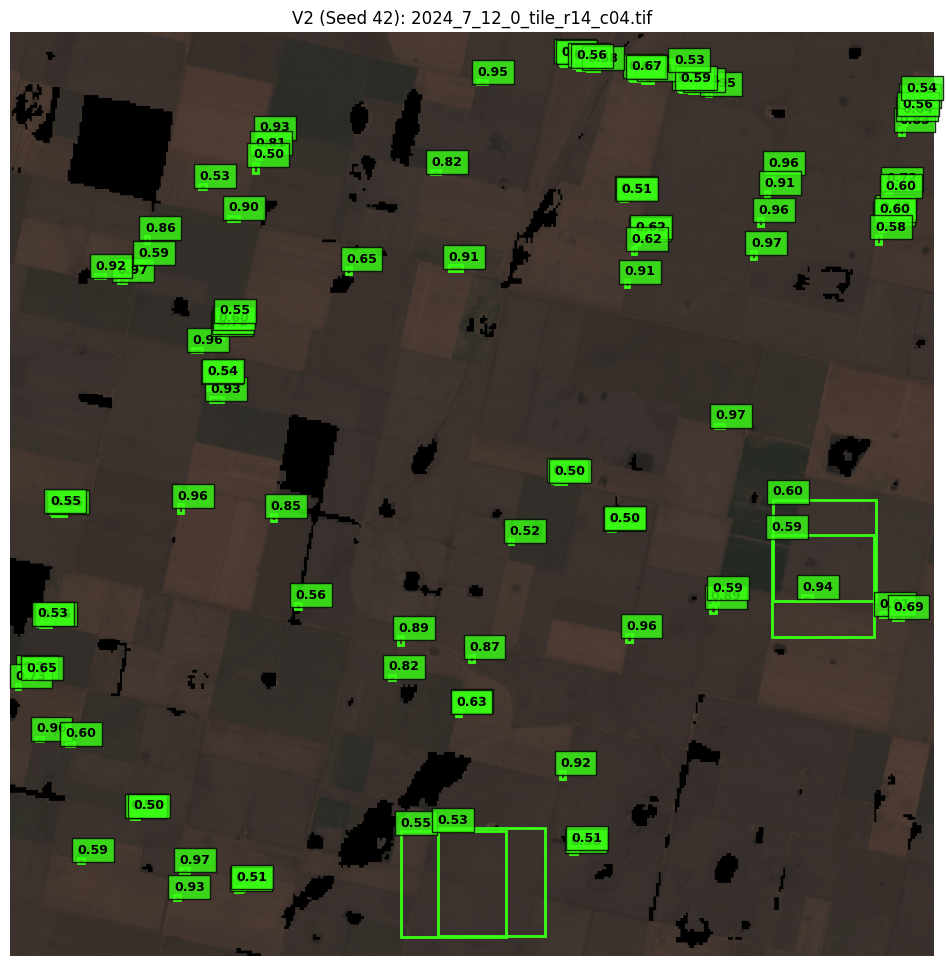

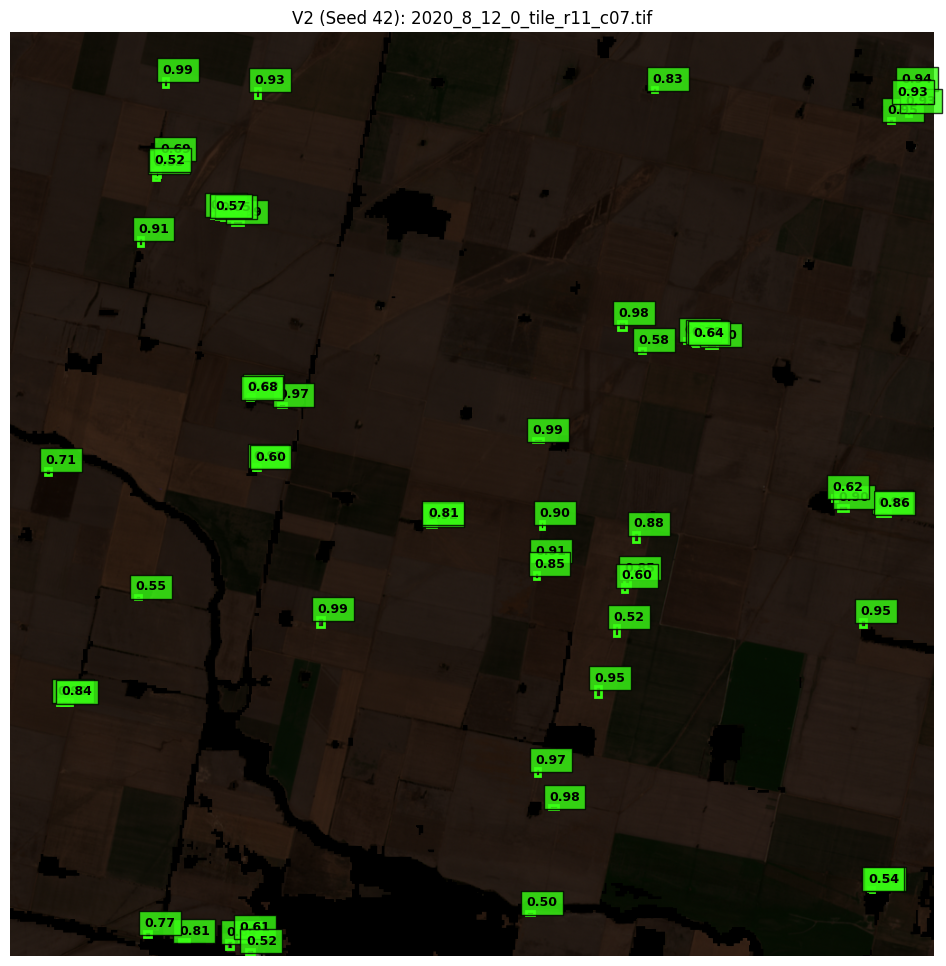

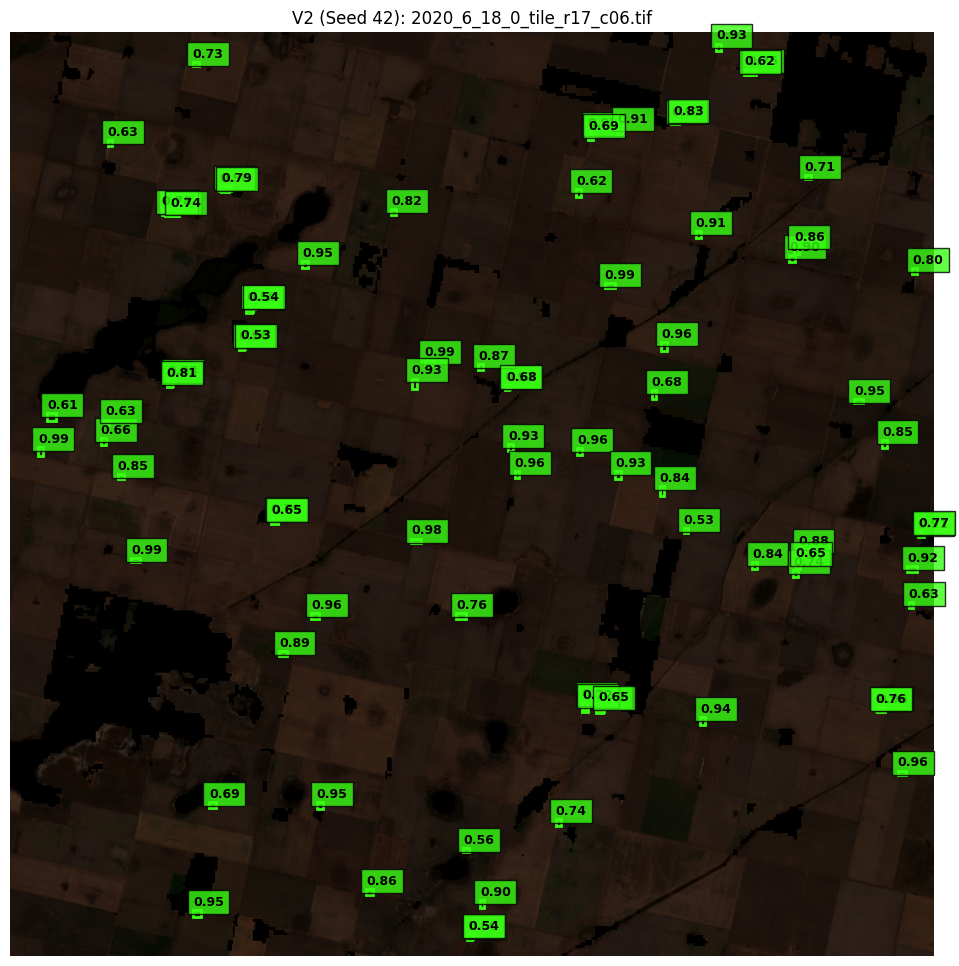

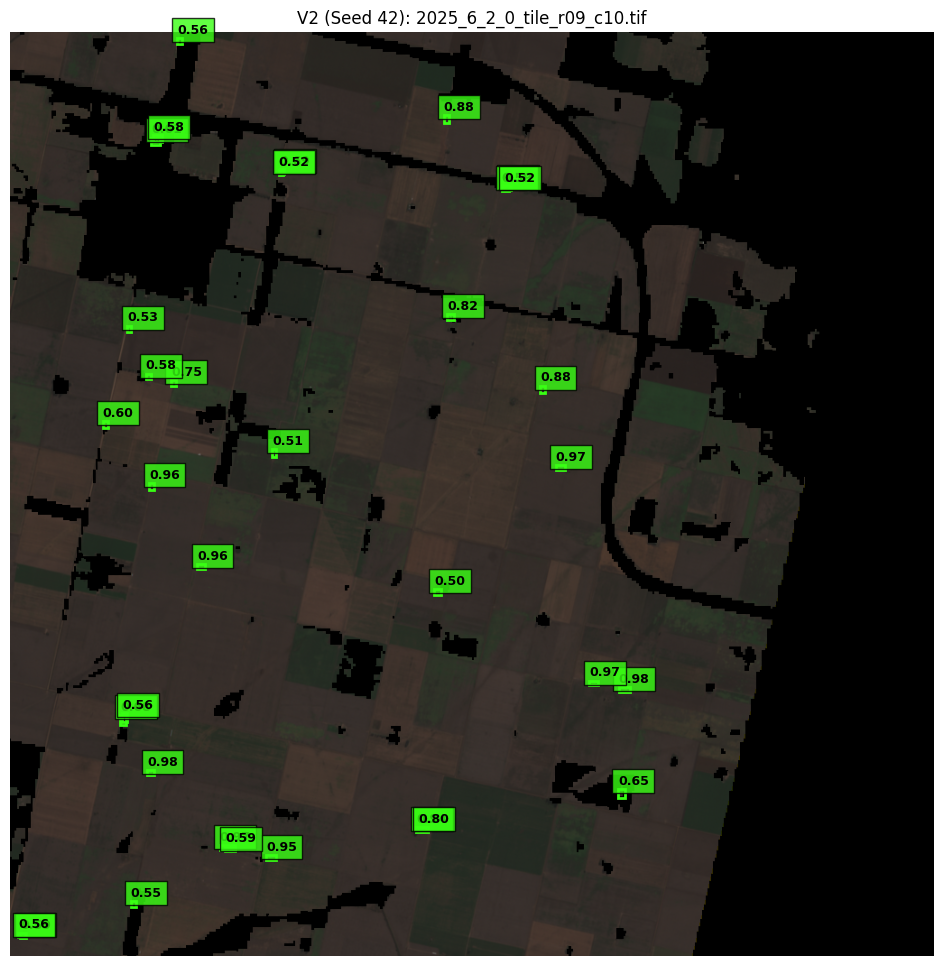

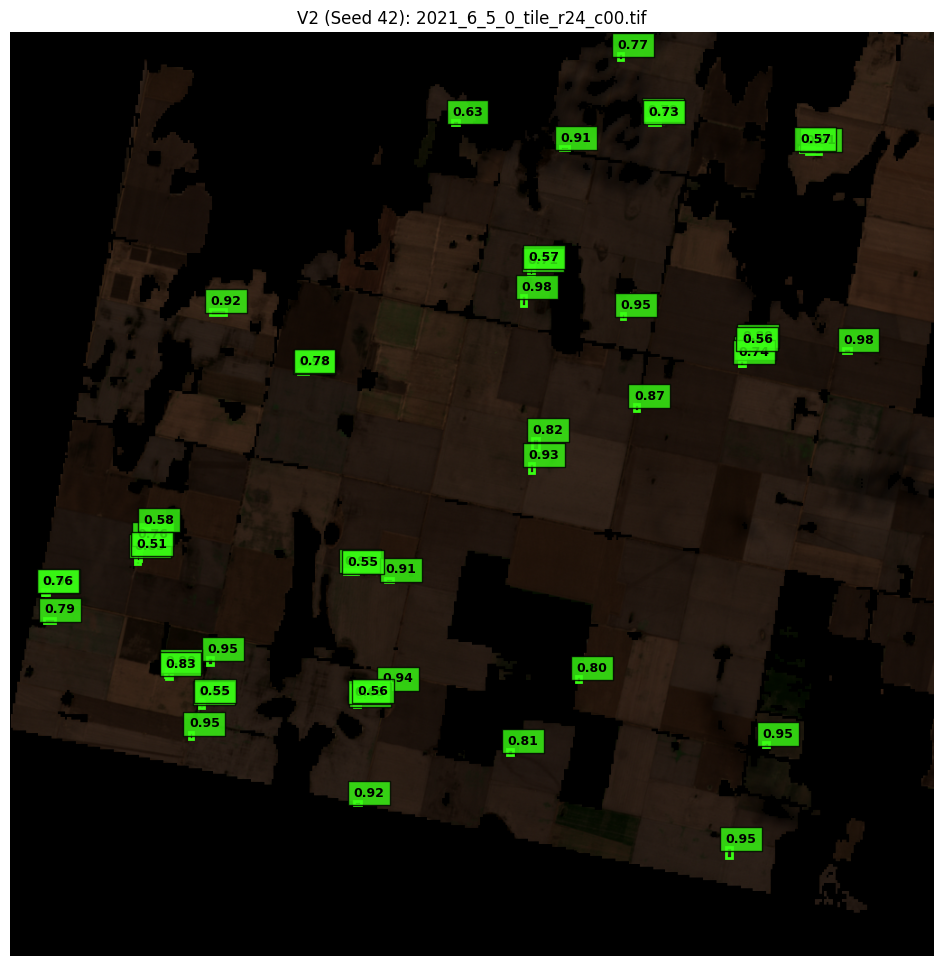

In [ ]:
import os
import torch
import torchvision
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
import random

# --- CONFIGURACIÓN V2 ---
MODEL_PATH = r"D:\Silos\modelo_silos_v2_optimizado.pth"
VAL_DIR = r"D:\Silos\Dataset_V2\val"
THRESHOLD = 0.5
SEED = 42  # Semilla fija para consistencia

# --- FIJAR SEMILLA ---
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- DEFINICIÓN DEL MODELO V2 (CORRECTA) ---
def get_model_v2_inference(num_classes):
    # Configuración de Anchors por niveles (tuplas separadas)
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    
    anchor_generator = AnchorGenerator(
        sizes=anchor_sizes,
        aspect_ratios=aspect_ratios
    )
    
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def preprocess_image(img_path):
    with rasterio.open(img_path) as src:
        try: img_data = src.read([1, 2, 3])
        except: img_data = src.read()[:3, :, :]
    
    img_data = np.nan_to_num(img_data.astype(np.float32), nan=0.0)
    max_val = np.max(img_data)
    if max_val > 255.0: img_data /= 10000.0
    elif max_val > 1.0: img_data /= 255.0
    img_data = np.clip(img_data, 0, 1)
    return torch.as_tensor(img_data, dtype=torch.float32)

def plot_prediction(img_tensor, prediction, threshold=0.5, filename=""):
    img_numpy = img_tensor.cpu().numpy().transpose(1, 2, 0)
    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(img_numpy)
    ax.set_title(f"V2 (Seed {SEED}): {filename}")
    
    boxes = prediction[0]['boxes'].cpu().detach().numpy()
    scores = prediction[0]['scores'].cpu().detach().numpy()
    
    found = False
    for box, score in zip(boxes, scores):
        if score >= threshold:
            found = True
            xmin, ymin, xmax, ymax = box
            # Caja verde lima brillante
            rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2, edgecolor='#39FF14', facecolor='none')
            ax.add_patch(rect)
            ax.text(xmin, ymin-5, f'{score:.2f}', color='black', fontsize=9, weight='bold', bbox=dict(facecolor='#39FF14', alpha=0.8))
    
    if not found:
        print(f"-> {filename}: Sin detecciones > {threshold}")
    
    plt.axis('off')
    plt.show()

def main_visual():
    device = torch.device('cpu')
    if not os.path.exists(MODEL_PATH): 
        print("No se encuentra el modelo.")
        return

    print(f"Cargando modelo V2 (Seed: {SEED})...")
    model = get_model_v2_inference(num_classes=2)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    
    # IMPORTANTE: Ordenar para garantizar que la semilla elija los mismos archivos
    val_images = sorted([f for f in os.listdir(VAL_DIR) if f.endswith('.tif')])
    
    if not val_images: return

    samples = random.sample(val_images, min(5, len(val_images)))
    
    print(f"Visualizando las siguientes {len(samples)} imágenes:")
    for s in samples: print(f" - {s}")

    for img_name in samples:
        img_path = os.path.join(VAL_DIR, img_name)
        img_tensor = preprocess_image(img_path)
        with torch.no_grad():
            prediction = model([img_tensor.to(device)])
        plot_prediction(img_tensor, prediction, THRESHOLD, img_name)

if __name__ == "__main__":
    main_visual()

In [6]:
import os
import torch
import rasterio
import geopandas as gpd
from shapely.geometry import box
import numpy as np
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
import random

# --- CONFIGURACIÓN V2 ---
MODEL_PATH = r"D:\Silos\modelo_silos_v2_optimizado.pth"
VAL_DIR = r"D:\Silos\Dataset_V2\val"
OUTPUT_DIR = r"D:\Silos\predicciones_individuales"
THRESHOLD = 0.5
SEED = 42  # DEBE SER EL MISMO QUE EN SCRIPT A

# --- FIJAR SEMILLA ---
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_model_v2_inference(num_classes):
    # Misma definición exacta que Script A
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    
    anchor_generator = AnchorGenerator(
        sizes=anchor_sizes,
        aspect_ratios=aspect_ratios
    )
    
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def preprocess_image(img_path):
    with rasterio.open(img_path) as src:
        try: img_data = src.read([1, 2, 3])
        except: img_data = src.read()[:3, :, :]
    img_data = np.nan_to_num(img_data.astype(np.float32), nan=0.0)
    max_val = np.max(img_data)
    if max_val > 255.0: img_data /= 10000.0
    elif max_val > 1.0: img_data /= 255.0
    img_data = np.clip(img_data, 0, 1)
    return torch.as_tensor(img_data, dtype=torch.float32)

def main_export_v2():
    device = torch.device('cpu')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    print(f"Generando Shapes V2 para la semilla {SEED}...")
    
    if not os.path.exists(MODEL_PATH): 
        print("Modelo no encontrado.")
        return

    model = get_model_v2_inference(num_classes=2)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    
    # 1. LISTAR Y ORDENAR
    val_images = sorted([f for f in os.listdir(VAL_DIR) if f.endswith('.tif')])
    if not val_images: return

    # 2. SELECCIONAR LA MISMA MUESTRA
    samples = random.sample(val_images, min(5, len(val_images)))
    
    print(f"Exportando shapefiles para las siguientes {len(samples)} imágenes:")

    for img_name in samples:
        print(f"--> Procesando: {img_name}")
        img_path = os.path.join(VAL_DIR, img_name)
        
        img_tensor = preprocess_image(img_path)
        with torch.no_grad():
            prediction = model([img_tensor.to(device)])
        
        boxes_px = prediction[0]['boxes'].cpu().numpy()
        scores = prediction[0]['scores'].cpu().numpy()
        
        geometries = []
        valid_scores = []
        
        with rasterio.open(img_path) as src:
            transform = src.transform
            crs = src.crs
            for box_px, score in zip(boxes_px, scores):
                if score >= THRESHOLD:
                    xmin, ymin, xmax, ymax = box_px
                    # Pixel -> Coordenadas Reales
                    x_min, y_max = rasterio.transform.xy(transform, ymin, xmin, offset='ul')
                    x_max, y_min = rasterio.transform.xy(transform, ymax, xmax, offset='ul')
                    geo_box = box(x_min, y_min, x_max, y_max)
                    geometries.append(geo_box)
                    valid_scores.append(float(score))
        
        if len(geometries) > 0:
            output_name = f"pred_{os.path.splitext(img_name)[0]}.shp"
            output_path = os.path.join(OUTPUT_DIR, output_name)
            gdf = gpd.GeoDataFrame({'filename': img_name, 'score': valid_scores}, geometry=geometries, crs=crs)
            gdf.to_file(output_path)
            print(f"   [OK] Shape guardado en: {output_path}")
        else:
            print(f"   [INFO] Sin detecciones > {THRESHOLD}")

    print(f"\n¡Listo! Revisa la carpeta {OUTPUT_DIR} y ábrelos en QGIS junto con sus TIFs.")

if __name__ == "__main__":
    main_export_v2()

Generando Shapes V2 para la semilla 42...
Exportando shapefiles para las siguientes 5 imágenes:
--> Procesando: 2024_7_12_0_tile_r14_c04.tif
   [OK] Shape guardado en: D:\Silos\predicciones_individuales\pred_2024_7_12_0_tile_r14_c04.shp
--> Procesando: 2020_8_12_0_tile_r11_c07.tif
   [OK] Shape guardado en: D:\Silos\predicciones_individuales\pred_2020_8_12_0_tile_r11_c07.shp
--> Procesando: 2020_6_18_0_tile_r17_c06.tif
   [OK] Shape guardado en: D:\Silos\predicciones_individuales\pred_2020_6_18_0_tile_r17_c06.shp
--> Procesando: 2025_6_2_0_tile_r09_c10.tif
   [OK] Shape guardado en: D:\Silos\predicciones_individuales\pred_2025_6_2_0_tile_r09_c10.shp
--> Procesando: 2021_6_5_0_tile_r24_c00.tif
   [OK] Shape guardado en: D:\Silos\predicciones_individuales\pred_2021_6_5_0_tile_r24_c00.shp

¡Listo! Revisa la carpeta D:\Silos\predicciones_individuales y ábrelos en QGIS junto con sus TIFs.
